# Code to generate the thesis plots

To generate different plots depending on different simulations change the simulation path before the .csv filename. The last two simulations do not have the final stats inside the .csv files because of the error reported by Francesco in the group chat, however the file packet_result.csv was correctly populated and it is the one used to generate the first two plots, so we can use those simulations anyway. If you try you see that the results are very close to ones presented in the thesis.

In [1]:
low_load_sim = "project/simulations/sim_2025-07-23_12:43:21/"
heavy_load_sim = "project/simulations/sim_2025-07-23_16:57:06/"
sim_base_path = "project/simulations/sim_2025-07-22_10:37:20/"

graph_path = "project/file/graph_networkx_15_nodes.json"

# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import json

## Heatmap of the fraction of bits received by each node from the other nodes in the network

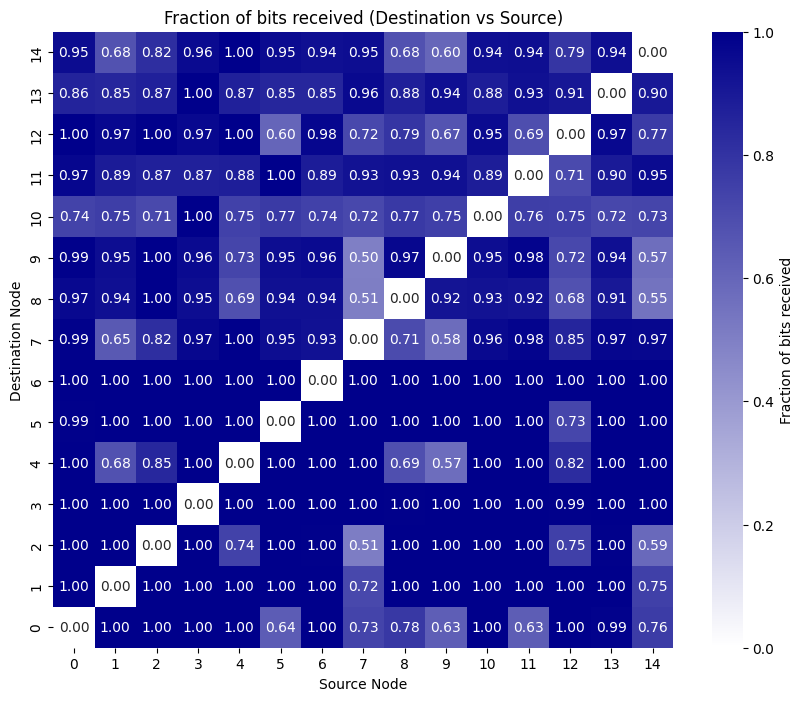

In [3]:
df = pd.read_csv(low_load_sim + "packet_result.csv")
df["Sent"] = df["Sent"].astype(bool)
df["Delivered"] = df["Delivered"].astype(bool)

df_sent = df[df["Sent"] == True]

# Group by Source and Destination and compute sent and delivered counts
grouped = df_sent.groupby(["Source", "Destination"]).agg(
    sent_packets=("Sent", "count"),
    delivered_packets=("Delivered", "sum")
).reset_index()

# Compute fraction of delivered over sent
grouped["fraction_received"] = grouped["delivered_packets"] / grouped["sent_packets"]

heatmap_data = grouped.pivot(index="Destination", columns="Source", values="fraction_received")
# Replace NaN with 0
heatmap_data = heatmap_data.fillna(0)

# Strip 'node' prefix from rows and columns
heatmap_data.index = heatmap_data.index.str.replace("node", "", regex=False).astype(int)
heatmap_data.columns = heatmap_data.columns.str.replace("node", "", regex=False).astype(int)

# Sort rows and columns
heatmap_data = heatmap_data.sort_index(axis=0)  # rows
heatmap_data = heatmap_data.sort_index(axis=1)  # columns

heatmap_data = heatmap_data.reindex(index=heatmap_data.index[::-1])

cmap = mcolors.LinearSegmentedColormap.from_list("white_to_darkblue", ["white", "#00008B"])
plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Fraction of bits received"}
)

plt.title("Fraction of bits received (Destination vs Source)")
plt.xlabel("Source Node")
plt.ylabel("Destination Node")
plt.show()

## Number of received bits for each node

Number of correctly received packets per destination node:
Destination
0     7742
1     8946
2     8179
3     9819
4     8255
5     9232
6     9681
7     8081
8     7819
9     7876
10    7348
11    8635
12    7919
13    8620
14    7969
Name: count, dtype: int64


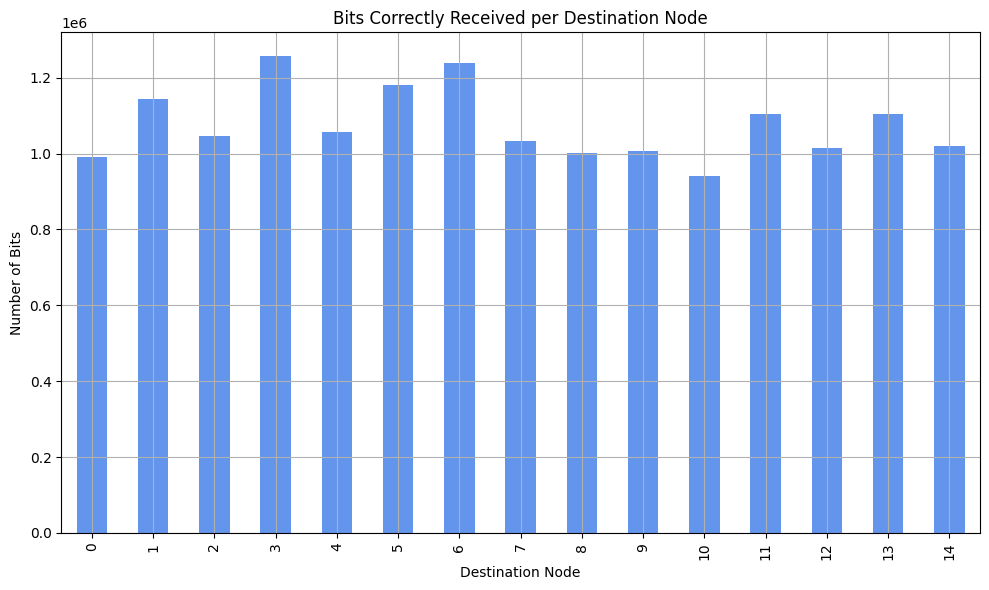

In [4]:
df_packets = pd.read_csv(low_load_sim + "packet_result.csv")
df_packets["Destination"] = df_packets["Destination"].str.extract(r"(\d+)", expand=False).astype(int)

# Filter only delivered packets
delivered_packets = df_packets[df_packets["Delivered"] == True]

# Count received packets per destination node
received_counts = delivered_packets["Destination"].value_counts().sort_index()
received_bits = received_counts * 128

print("Number of correctly received packets per destination node:")
print(received_counts)

plt.figure(figsize=(10, 6))
received_bits.plot(kind="bar", color="cornflowerblue")
plt.title("Bits Correctly Received per Destination Node")
plt.xlabel("Destination Node")
plt.ylabel("Number of Bits")
plt.grid(True)
plt.tight_layout()
plt.show()

## Average of correctly received bits by destination nodes for paths of different lengths

In [5]:
with open(graph_path) as f:
    data = json.load(f)
G = nx.node_link_graph(data)

all_pairs_lengths = dict(nx.all_pairs_shortest_path_length(G))

# Extract unique path lengths
unique_lengths = set()

for source, length_dict in all_pairs_lengths.items():
    for target, length in length_dict.items():
        if source != target:
            unique_lengths.add(length)

print("Unique shortest path lengths between node pairs:", sorted(unique_lengths))

Unique shortest path lengths between node pairs: [1, 2, 3, 4]


/home/force/Documents/GitHub/QKD_Simulator/.venv/lib/python3.11/site-packages/networkx/readwrite/json_graph/node_link.py:290: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


## Success probability for each path length

## Centrality values for each node

This plot is useless for us, I did it for sport as we say in Italy.

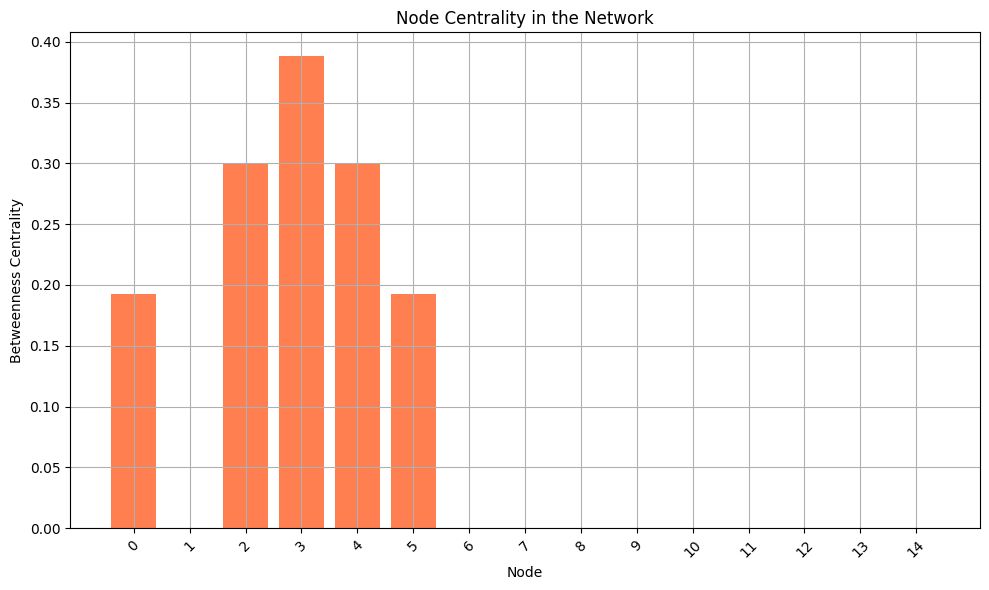

In [6]:
centrality = nx.betweenness_centrality(G)

plt.figure(figsize=(10, 6))
plt.bar(centrality.keys(), centrality.values(), color="coral")
plt.xlabel("Node")
plt.ylabel("Betweenness Centrality")
plt.title("Node Centrality in the Network")
plt.xticks(ticks=range(len(centrality)), labels=list(centrality.keys()), rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()